In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import response_factor as rsp

# 松尾の留数定理による単位応答の計算

## 参考文献
松尾陽、横山浩一、石野久彌、川元昭吾：空調設備の動的熱負荷計算入門

## 使用するライブラリ
numpy
math
Tuple

## 補足説明
Laplace逆変換には、Heavisideの部分分数展開定理を用いて4端子行列のB(s)=0をニュートンラプソン法で求めている。重根が出る場合はうまく根が求まっていないため、calc_Bsを用いて重根をチェックするとよい

## 多層壁熱抵抗の計算

## 試算条件
| 建材 | 厚さ[mm] | 熱伝導率[W/(m･K)] | 容積比熱[J/(m3･K)] |
| ---- | ---- | ---- | ---- |
| 室内表面熱伝達 | - | 9 | 0 |
| 吹付け硬質ウレタンフォームA 種1 | 50 | 0.034 | 61 |
| コンクリート | 100 | 1.6 | 2000 |
| 室外側表面熱伝達 | - | 23 | 0 |

In [46]:
type = '床'  # '外壁'、'屋根'、'床'

if type == '外壁':
    # 室内側熱伝達抵抗
    # 石膏ボード12mm
    # 非密閉中空層
    # 吹付硬質ウレタンフォームA種１　50mm
    # コンクリート150mm
    # モルタル20mm
    # タイル8mm
    # 室外側熱伝達抵抗
    rs = np.array([
            1.0 / 9.0,
            0.012 / 0.22,
            0.07,
            0.05 / 0.022,
            0.15 / 1.6,
            0.02 / 1.5,
            0.008 / 1.3,
            1.0 / 23.0
        ])
    
    cs = np.array([
            0.0,
            830 * 0.012 * 1000,
            0.0,
            0.05 * 77 * 1000,
            0.15 * 2000 * 1000,
            0.02 * 1600 * 1000,
            0.008 * 2000 * 1000,
            0.0
    ])
elif type == '屋根':
    # 室外側熱伝達抵抗
    # コンクリート80mm
    # 押出法ポリスチレンフォーム保温板２種30mm
    # アスファルト類10mm
    # コンクリート150mm
    # 非密閉中空層
    # 石膏ボード9mm
    # ロックウール化粧吸音板12mm
    # 室内側熱伝達抵抗
    rs = np.array([
            1.0 / 9.0,
            0.012 / 0.064,
            0.009 / 0.22,
            0.07,
            0.15 / 1.6,
            0.01 / 0.11,
            0.03 / 0.034,
            0.08 / 1.6,
            1.0 / 23.0
        ])
    cs = np.array([
            0.0,
            0.012 * 294 * 1000,
            0.009 * 830 * 1000,
            0.0,
            0.15 * 2000 * 1000,
            0.01 * 920 * 1000,
            0.03 * 36 * 1000,
            0.03 * 2000 * 1000,
            1.0 / 23.0
    ])
elif type == '床':
    # 室内側熱伝達抵抗
    # カーペット類7mm
    # スチール3mm
    # 非密閉中空層
    # コンクリート150mm
    # 非密閉中空層
    # 石膏ボード9mm
    # ロックウール化粧吸音板12mm
    # 室外側熱伝達抵抗
    rs = np.array([
            1.0 / 9.0,
            0.007 / 0.08,
            0.003 / 55,
            0.07,
            0.15 / 1.6,
            0.07,
            0.009 / 0.22,
            0.012 / 0.064,
            1.0 / 23.0
        ])
    cs = np.array([
            0.0,
            0.007 * 320 * 1000,
            0.003 * 3600 * 1000,
            0.0,
            0.15 * 2000 * 1000,
            0.0,
            0.009 * 830 * 1000,
            0.012 * 294 * 1000,
            0.0
    ])

## 根の計算

In [47]:
(a0, aa, at, alpha) = rsp.calc_alpha_matsuo_method(rs=rs, cs=cs, i_max=15)
print(f"a0: {a0}, aa: {aa}, at: {at}, alpha: {alpha}")

a0: 1.4198434312396546, aa: [1.9820194734105998e+00 3.9771919392346772e-01 6.7348379964575389e-01
 6.4546391600870512e-01 1.9943000093865781e-01 2.6514159330770299e-02
 4.8148589078054272e-03 1.8430624911419382e-03 5.5532636842624374e-05
 1.3775535695259619e-03 2.8603722412678511e-03 2.3940048805029845e+00
 1.4364542879506127e-02 2.7989217927086146e-04 5.6427632651343763e-06], at: [-1.61015880771276    0.3161227043460144 -0.487932641044191
  0.7353926804383975 -0.4116646822929486  0.0464299702638197
 -0.0128166364615757  0.0160850381445811 -0.0170792179523776
  0.0077457050947886 -0.004592297539737   0.0111137234978368
 -0.0098624586687972  0.0036392328243487 -0.0032235705004377], alpha: [2.0311192840320737e-05 3.6032323207306895e-04 1.1537198870600544e-03
 1.6342506320028028e-03 2.0395907268299326e-03 3.4343815508433078e-03
 5.8235363443098617e-03 8.9373658446031852e-03 1.0443361202091774e-02
 1.2839699666243274e-02 1.7377440650204391e-02 2.1340974073168095e-02
 2.2637431248170813e-02

In [48]:
# パラメータを基準化
print("\n=== パラメータを基準化 ===")
aa_n = aa / a0
at_n = at / a0
np.set_printoptions(precision=16, suppress=False)
print(f"aa_n: {aa_n}")
print(f"at_n: {at_n}")


=== パラメータを基準化 ===
aa_n: [1.3959422777200958e+00 2.8011482475657340e-01 4.7433666616166281e-01
 4.5460217782263179e-01 1.4045914961520581e-01 1.8674002180381951e-02
 3.3911196135207738e-03 1.2980744570778302e-03 3.9111803189552559e-05
 9.7021512317258126e-04 2.0145687745095116e-03 1.6861048393292188e+00
 1.0116990763527041e-02 1.9712890387251340e-04 3.9742151430089180e-06]
at_n: [-1.1340396921841884  0.2226461716768376 -0.3436524269568094
  0.5179392771471512 -0.2899366741680294  0.0327007677341452
 -0.0090267956167431  0.0113287407545615 -0.0120289445840278
  0.0054553234000075 -0.003234368972449   0.0078274288934333
 -0.0069461593101053  0.0025631226262542 -0.0022703704010683]


## 単位応答の計算

In [49]:
phi_a, phi_t = rsp.calc_step_respose_factor(aa=aa, at=at, alpha=alpha, a0=a0, n_max=50, delta_t=900)

# 二等辺三角波励振の応答係数の計算

In [50]:
rft_a, rft_t = rsp.calc_triangle_response_factor(aa=aa, at=at, alpha=alpha, a0=a0, n_max=50, delta_t=900)

# 4端子行列のB(s)を取得

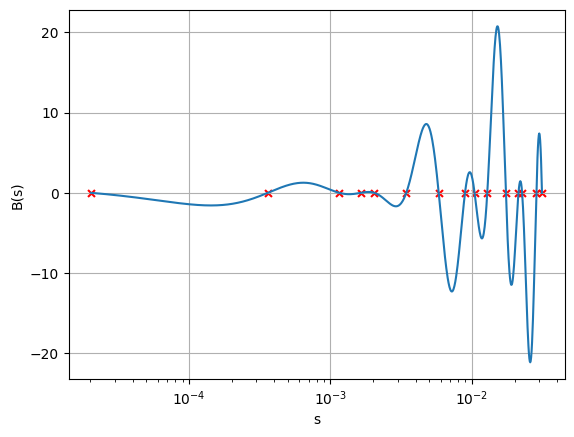

In [51]:
laps, Bs = rsp.calc_Bs(rs=rs, cs=cs, alpha=alpha)
zero = np.zeros_like(alpha)
plt.scatter(laps, Bs, marker="None")
plt.scatter(alpha, zero, marker='x', c='r', s=25)
plt.plot(laps, Bs)
plt.xlabel('s')
plt.ylabel('B(s)')
plt.xscale('log')
plt.grid()
plt.show()

## グラフ描画

In [52]:
pd_phi_a = pd.Series(phi_a)
pd_phi_t = pd.Series(phi_t)
pd_rft_a = pd.Series(rft_a)
pd_rft_t = pd.Series(rft_t)

<Axes: title={'center': 'rft_t'}>

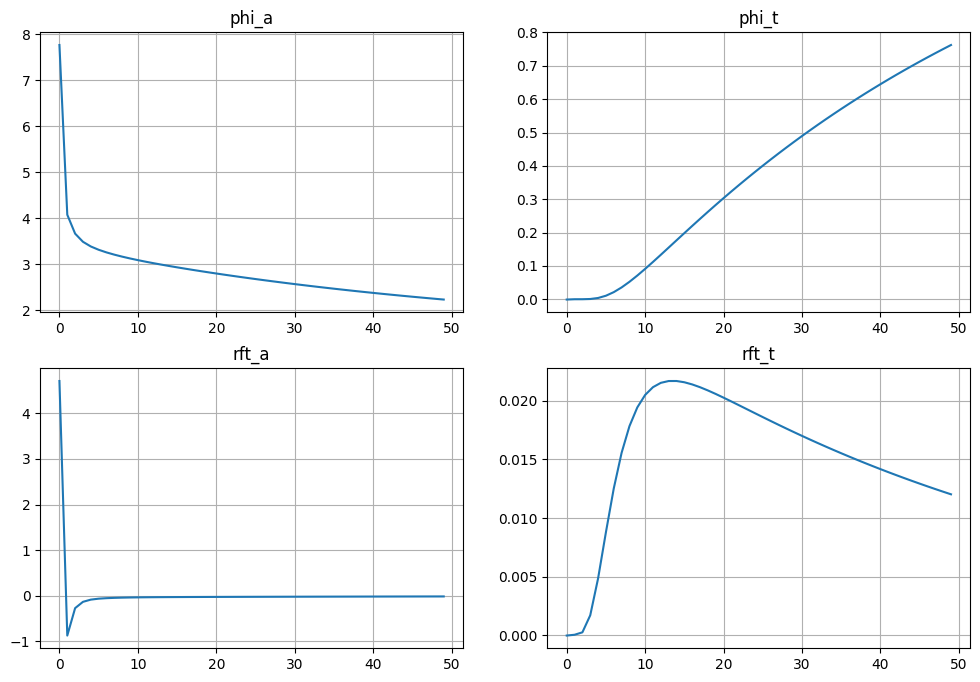

In [53]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

pd_phi_a.plot(ax=axes[0, 0], kind='line', title='phi_a', grid=True)
pd_phi_t.plot(ax=axes[0, 1], kind='line', title='phi_t', grid=True)
pd_rft_a.plot(ax=axes[1, 0], kind='line', title='rft_a', grid=True)
pd_rft_t.plot(ax=axes[1, 1], kind='line', title='rft_t', grid=True)